In [4]:
import os
import numpy as np
import pandas as pd

opened = []

masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/ALL_STATIONS_ALL_DAYS_COMBINED.csv'

# Load the master list of stations
total_df = pd.read_csv(masterlist)
csv_dir = (
    '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/'
    'CSMUB/RESULTS/TIMESERIES/DAILY_PREDICTED/CSV'
)

records = []

for fname in os.listdir(csv_dir):
    if not fname.endswith('.csv'):
        continue

    station_no = int(fname.replace('.csv', ''))
    df = pd.read_csv(os.path.join(csv_dir, fname))

    q_obs = df['Q_actual'].values
    q_pred = df['Q_pred'].values

    # Drop NaNs safely
    mask = np.isfinite(q_obs) & np.isfinite(q_pred)
    q_obs = q_obs[mask]
    q_pred = q_pred[mask]

    if len(q_obs) == 0:
        continue

    mae = np.mean(np.abs(q_pred - q_obs))
    mean_q = np.mean(q_obs)

    if mean_q <= 0:
        continue

    nmae = mae / mean_q

    records.append({
        'grdc_no': station_no,
        'MAE': mae,
        'Q_mean': mean_q,
        'nMAE': nmae
    })

station_error = pd.DataFrame(records)


/tmp/ipykernel_449048/3444280652.py:10: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  total_df = pd.read_csv(masterlist)


In [5]:
station_meta = (
    total_df
    .groupby('grdc_no')
    .agg({
        'lat': 'first',
        'area_delin': 'first',
        'P': 'mean',
        'max_slope': 'first'
    })
    .reset_index()
)

station_error = station_error.merge(
    station_meta,
    on='grdc_no',
    how='left'
)


In [6]:
def plot_feature_vs_station_error_colored(df, feature_col, feature_name, bins):

    plt.figure(figsize=(10, 6))

    df = df.copy()
    df['feature_bin'] = pd.cut(df[feature_col], bins=bins, right=False)

    bin_error = df.groupby('feature_bin', observed=True)['nMAE'].mean()
    bin_counts = df.groupby('feature_bin', observed=True)['nMAE'].count()

    colors = plt.cm.cool(bin_counts / bin_counts.max())

    x = np.arange(len(bin_error))
    bars = plt.bar(x, bin_error.values, color=colors, width=0.8)

    labels = [str(i) for i in bin_error.index]
    plt.xticks(x, labels)

    for bar, count in zip(bars, bin_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'n={count}',
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.xlabel(feature_name)
    plt.ylabel('Normalized MAE (MAE / mean Q)')
    plt.title(f'Normalized MAE vs {feature_name}')

    sm = plt.cm.ScalarMappable(
        cmap='cool',
        norm=plt.Normalize(
            vmin=bin_counts.min(),
            vmax=bin_counts.max()
        )
    )
    sm.set_array([])
    cbar = plt.colorbar(sm)
    cbar.set_label('Stations per bin')

    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

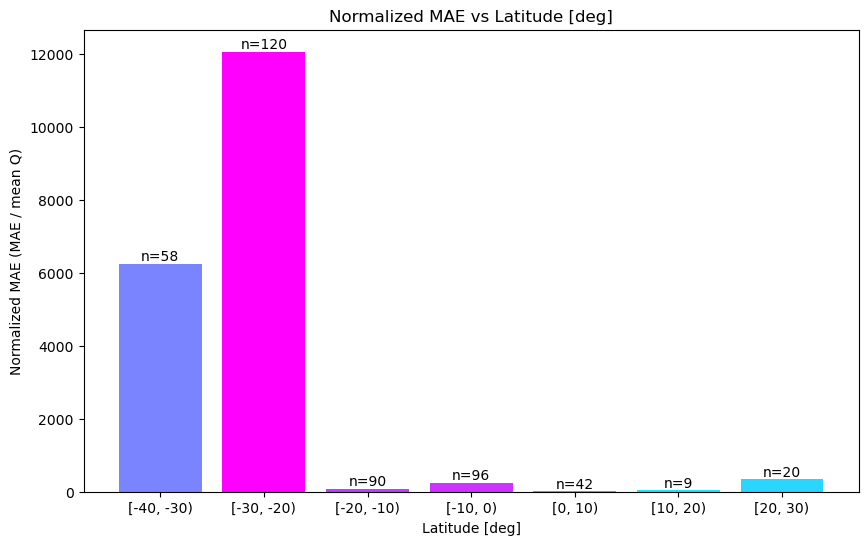

In [8]:
import matplotlib.pyplot as plt

lat_bins   = np.arange(-40, 40, 10)
area_bins  = np.arange(1e4, 5.5e5, 5e4)
P_bins     = np.arange(0, 11, 1)
slope_bins = np.arange(0, 60, 5)

plot_feature_vs_station_error_colored(
    station_error, 'lat', 'Latitude [deg]', lat_bins
)

plot_feature_vs_station_error_colored(
    station_error, 'area_delin', 'Basin Area [km²]', area_bins
)

plot_feature_vs_station_error_colored(
    station_error, 'P', 'Precipitation [mm/day]', P_bins
)

plot_feature_vs_station_error_colored(
    station_error, 'max_slope', 'Max Slope [deg]', slope_bins
)